# 05 Interpretation
SHAP-based explanations, partial dependence plots, targeted intervention logic, and business recommendations.

Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value ' ' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
PermutationExplainer explainer: 251it [01:49,  2.18it/s]                         


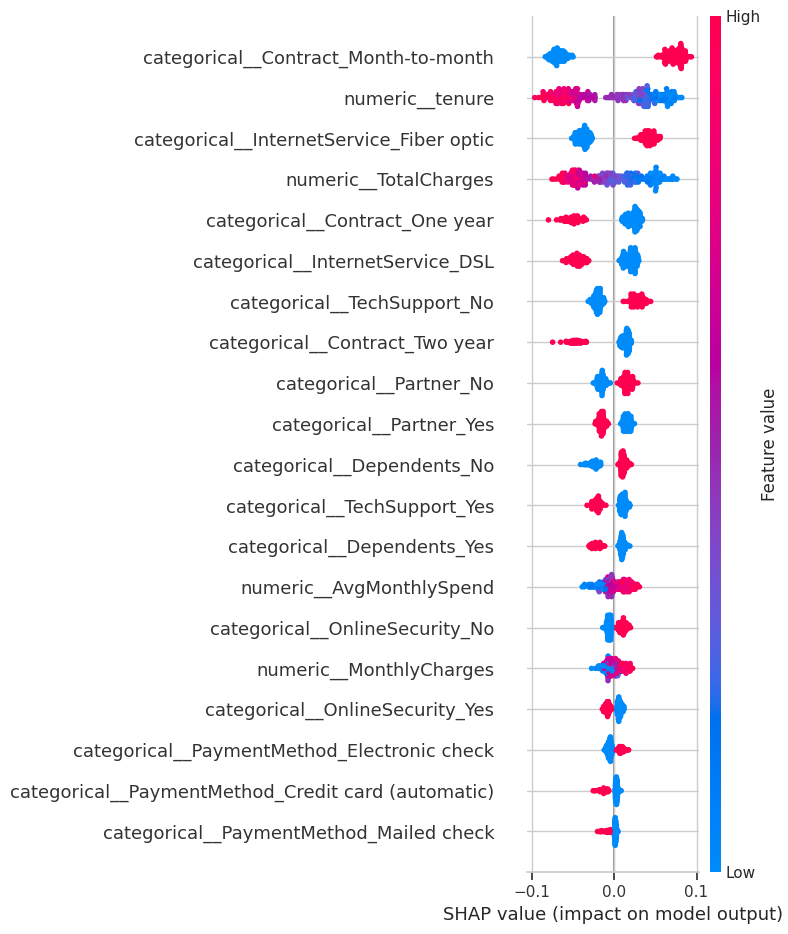

Top five churn drivers:
categorical__Contract_Month-to-month        0.071604
numeric__tenure                             0.047993
categorical__InternetService_Fiber optic    0.039672
numeric__TotalCharges                       0.035404
categorical__Contract_One year              0.030073
dtype: float64


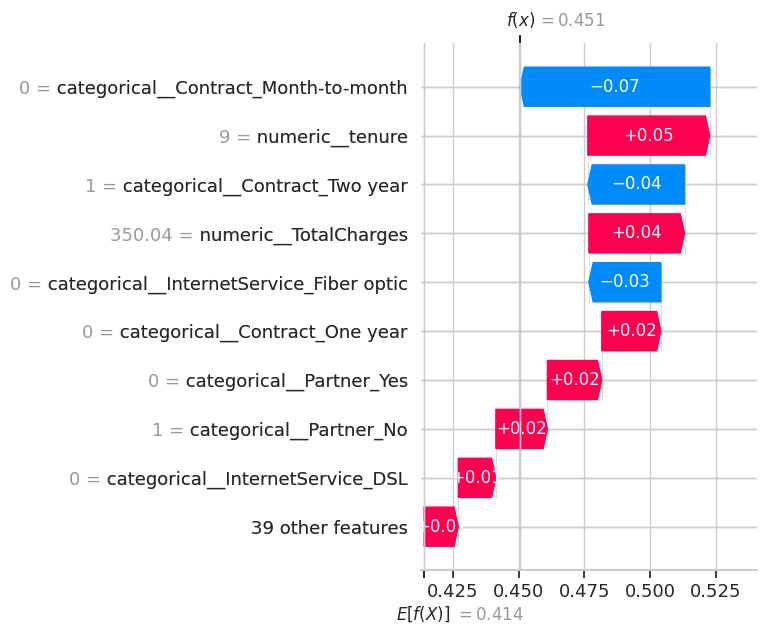

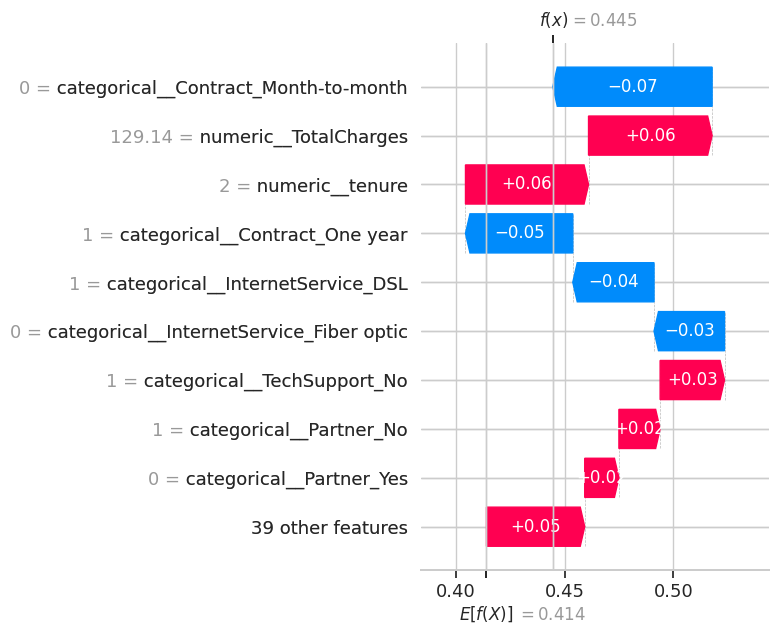

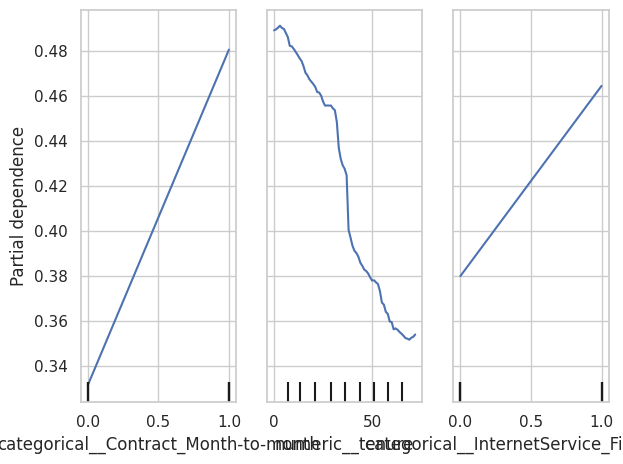

Highest-risk segments from the classification data:
Contract        InternetService
Month-to-month  Fiber optic        0.487507
                No                 0.312849
                DSL                0.256868
Two year        Fiber optic        0.232227
One year        Fiber optic        0.208820
Name: churn_binary, dtype: float64


/home/avinash/Projects/Churn-Prediction-AI/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.523e+03, tolerance: 1.419e+02
  model = cd_fast.enet_coordinate_descent(
/home/avinash/Projects/Churn-Prediction-AI/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.497e+02, tolerance: 1.427e+02
  model = cd_fast.enet_coordinate_descent(
/home/avinash/Projects/Churn-Prediction-AI/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations

Target the 100 customers with the highest churn probability because they concentrate the most expected lost revenue.
Model net value: 24500.0
Random targeting net value: 8481.55
Incremental ROI versus random targeting: 3.2037
Suggested pricing strategy: keep high-risk, high-value segments on longer contracts with bundled discounts rather than applying blanket discounts.


In [2]:
%matplotlib inline
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.inspection import PartialDependenceDisplay

notebook_root = Path.cwd().resolve()
if not (notebook_root / 'src').exists() and (notebook_root.parent / 'src').exists():
    notebook_root = notebook_root.parent
if str(notebook_root) not in sys.path:
    sys.path.insert(0, str(notebook_root))

from src.classifiers import benchmark_classifiers
from src.data_loader import load_telco_data, split_train_val_test
from src.preprocessing import prepare_train_val_test_features
from src.regressors import benchmark_regressors, extract_linear_coefficients
from src.utils import PROJECT_ROOT, ensure_directory, load_pickle, save_pickle, set_random_seed

set_random_seed(42)
figures_dir = ensure_directory(PROJECT_ROOT / 'reports' / 'figures')
models_dir = ensure_directory(PROJECT_ROOT / 'models')

frame = load_telco_data()
classification_train, classification_validation, classification_test = split_train_val_test(frame, target_column='Churn', stratify=True, random_state=42)
X_train, y_train, X_validation, y_validation, X_test, y_test, preprocessor, feature_names = prepare_train_val_test_features(
    classification_train,
    classification_validation,
    classification_test,
    target_column='Churn',
    drop_columns=['customerID'],
    scaler='none',
)

classifier_path = models_dir / 'best_classifier.pkl'
if classifier_path.exists():
    best_classifier = load_pickle(classifier_path)
else:
    _, best_classifier, _ = benchmark_classifiers(
        X_train,
        y_train,
        X_validation,
        y_validation,
        X_test,
        y_test,
        random_state=42,
        save_path=classifier_path,
    )

background = X_train.sample(min(200, len(X_train)), random_state=42)
evaluation_frame = X_test.sample(min(250, len(X_test)), random_state=42)

def churn_probability(data):
    if not isinstance(data, pd.DataFrame):
        data = pd.DataFrame(data, columns=X_train.columns)
    return best_classifier.predict_proba(data)[:, 1]

explainer = shap.Explainer(churn_probability, background)
shap_values = explainer(evaluation_frame)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values.values, evaluation_frame, show=False)
plt.tight_layout()
plt.savefig(figures_dir / 'shap_summary_plot.png', bbox_inches='tight')
plt.show()

mean_abs_shap = pd.Series(np.abs(shap_values.values).mean(axis=0), index=evaluation_frame.columns).sort_values(ascending=False)
top_features = mean_abs_shap.head(3).index.tolist()
print('Top five churn drivers:')
print(mean_abs_shap.head(5))

churn_indices = y_test[y_test == 1].index.tolist()
retained_indices = y_test[y_test == 0].index.tolist()
churn_index = churn_indices[0] if churn_indices else y_test.index[0]
retained_index = retained_indices[0] if retained_indices else y_test.index[-1]

for label, sample_index in [('churned', churn_index), ('retained', retained_index)]:
    sample = X_test.loc[[sample_index]]
    sample_explanation = explainer(sample)
    shap.plots.waterfall(sample_explanation[0], show=False)
    plt.tight_layout()
    plt.savefig(figures_dir / f'shap_local_{label}.png', bbox_inches='tight')
    plt.show()

PartialDependenceDisplay.from_estimator(best_classifier, X_test, features=top_features, kind='average')
plt.tight_layout()
plt.savefig(figures_dir / 'partial_dependence_top_features.png', bbox_inches='tight')
plt.show()

print('Highest-risk segments from the classification data:')
risk_table = frame.assign(churn_binary=frame['Churn'].astype(str).str.lower().map({'yes': 1, 'no': 0}))
print(risk_table.groupby(['Contract', 'InternetService'])['churn_binary'].mean().sort_values(ascending=False).head(5))

regression_train, regression_validation, regression_test = split_train_val_test(frame, target_column='MonthlyCharges', stratify=False, random_state=42)
Xr_train, yr_train, Xr_validation, yr_validation, Xr_test, yr_test, regression_preprocessor, regression_feature_names = prepare_train_val_test_features(
    regression_train,
    regression_validation,
    regression_test,
    target_column='MonthlyCharges',
    drop_columns=['customerID', 'Churn'],
    scaler='none',
)

regressor_path = models_dir / 'best_regressor.pkl'
if regressor_path.exists():
    best_regressor = load_pickle(regressor_path)
else:
    _, best_regressor, _ = benchmark_regressors(
        Xr_train,
        yr_train,
        Xr_validation,
        yr_validation,
        Xr_test,
        yr_test,
        random_state=42,
        save_path=regressor_path,
    )

regressor_estimator = getattr(best_regressor, 'named_steps', {}).get('model', best_regressor)
if hasattr(regressor_estimator, 'coef_'):
    coefficient_table = extract_linear_coefficients(best_regressor, regression_feature_names)
    print('Pricing drivers from linear regression coefficients:')
    print(coefficient_table.head(8))
elif hasattr(regressor_estimator, 'feature_importances_'):
    importance_table = pd.Series(regressor_estimator.feature_importances_, index=regression_feature_names).sort_values(ascending=False)
    print('Pricing drivers from tree feature importance:')
    print(importance_table.head(8))

test_probabilities = best_classifier.predict_proba(X_test)[:, 1]
target_customers = X_test.assign(actual_churn=y_test, churn_probability=test_probabilities).sort_values('churn_probability', ascending=False).head(100)
model_expected_churners = int(target_customers['actual_churn'].sum())
random_expected_churners = float(y_test.mean() * 100)
model_revenue_saved = model_expected_churners * 500
random_revenue_saved = random_expected_churners * 500
model_intervention_cost = 100 * 50
random_intervention_cost = 100 * 50
model_net_value = model_revenue_saved - model_intervention_cost
random_net_value = random_revenue_saved - random_intervention_cost
roi = (model_net_value - random_net_value) / model_intervention_cost if model_intervention_cost else np.nan

print('Target the 100 customers with the highest churn probability because they concentrate the most expected lost revenue.')
print('Model net value:', round(float(model_net_value), 2))
print('Random targeting net value:', round(float(random_net_value), 2))
print('Incremental ROI versus random targeting:', round(float(roi), 4))
print('Suggested pricing strategy: keep high-risk, high-value segments on longer contracts with bundled discounts rather than applying blanket discounts.')